# Car Price Prediction - Exploratory Data Analysis

## Table of Contents
1. [Dataset Overview](#dataset-overview)
2. [Data Quality Assessment](#data-quality-assessment) 
3. [Numerical Features Analysis](#numerical-features-analysis)
4. [Categorical Features Analysis](#categorical-features-analysis)
5. [Feature Engineering](#feature-engineering)
6. [Summary Visualizations Dashboard](#summary-visualizations-dashboard)

---

## Dataset Overview

### Basic Dataset Information

In [1]:
from data_exploration import analyze_numerical_feature, suggest_transformations, analyze_categorical_feature, analyze_missing_data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
import warnings
import wordcloud
from wordcloud import WordCloud
#train_test_split
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')
import os
os.chdir('../')  # Change to project root directory
# Load data
train_relative_path = 'data/titanic.csv'
train_data = pd.read_csv(train_relative_path)
X, y = train_data.drop(columns=['survived']), train_data['survived']
X

# Dataset shape and basic info\
print("=== DATASET OVERVIEW ===")
print(f"Training set shape: {train_data.shape}")
print(f"Total features: {len(train_data.columns)}")

# Feature types
numerical_features = train_data.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = train_data.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical features: {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")

print("\n=== FEATURE TYPES ===")
print("Numerical:", numerical_features)
print("Categorical:", categorical_features)

# Display first few rows
print("\n=== SAMPLE DATA ===")
display(train_data.head())

=== DATASET OVERVIEW ===
Training set shape: (891, 15)
Total features: 15
Numerical features: 6
Categorical features: 7

=== FEATURE TYPES ===
Numerical: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical: ['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive']

=== SAMPLE DATA ===


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---

## Data Quality Assessment

### Missing Values Analysis

In [2]:
features = train_data.columns.tolist()
numerical_features = train_data.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = train_data.select_dtypes(include=['object']).columns.tolist()
print(f"len of features: {len(features)}")
print(f"len of numerical features: {len(numerical_features)}")
print(f"len of categorical features: {len(categorical_features)}")
print(50*"-")
print("numerical features in the dataset:")
for feature in numerical_features:
    # get the type of the feature
    feature_type = train_data[feature].dtype
    print(f"{feature}: {feature_type}")
print(50*"-")
print("categorical features in the dataset:")
for feature in categorical_features:
    feature_type = train_data[feature].dtype
    print(f"{feature}: {feature_type}")

len of features: 15
len of numerical features: 6
len of categorical features: 7
--------------------------------------------------
numerical features in the dataset:
survived: int64
pclass: int64
age: float64
sibsp: int64
parch: int64
fare: float64
--------------------------------------------------
categorical features in the dataset:
sex: object
embarked: object
class: object
who: object
deck: object
embark_town: object
alive: object


---

## Numerical Features Analysis

Each numerical feature will be analyzed for:
- **Statistics**: Basic descriptive statistics
- **Data Quality**: Missing values, outliers, invalid values
- **Distribution**: Shape, skewness, potential transformations
- **Suggested Transformations**: Recommended preprocessing steps

### Helper Functions for Analysis

## check nan presence in train and test data
they both have nan values so we will need to handle them appropriately but we cannot drop them entirely

In [3]:
# count how may rows contain at least one NaN value
num_rows_with_nan = train_data.isnull().any(axis=1).sum()
print(50*"-")
print(f"Number of rows with at least one NaN value: {num_rows_with_nan}")
# count how many rows are in the dataset
num_rows = train_data.shape[0]
print(f"Total number of rows in the dataset: {num_rows}")
# calculate the percentage of rows with at least one NaN value
percentage_rows_with_nan = (num_rows_with_nan / num_rows) * 100
print(f"Percentage of rows with at least one NaN value: {percentage_rows_with_nan:.2f}%")   

--------------------------------------------------
Number of rows with at least one NaN value: 709
Total number of rows in the dataset: 891
Percentage of rows with at least one NaN value: 79.57%


# to do lst for the prerocessing

-- survived is flagge as numerical but is a boolean
-- pcalss is clean but the values are 1,2,3 but they are categorical not numerical. we can discuss encoding
-- age has decimal numbers but we jst floor them
  - also the missing values can be imputed with the median
  -- age can als be log - transformed
-- sibs cna just stay the way it is
-- parch can just stay the way it is
-- fare has some outliers, may log is godd no mnissing values
-- sex can stay teh way it is, we just one hot encode it
-- embarked has some missig values but it is also very uselss so we cna jut impute the mode
-- who is redoundant
-- embark town is redoundant and also useless
-- deck is tricky because it has a lot of missing values but it is also very useful so we treat teh missing as a separate category and we one hot encode it

In [14]:
# imporrt one hot encoder and simple imputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    df_copy = df.copy()

    # floor the ages
    df_copy['age'] = df_copy['age'].apply(lambda x: np.floor(x) if pd.notnull(x) else x)
    df_copy['log_age'] = df_copy['age'].apply(lambda x: np.log(x) if pd.notnull(x) and x > 0 else x)
    df_copy['log_fare'] = df_copy['fare'].apply(lambda x: np.log(x) if pd.notnull(x) and x > 0 else x)

    # encode sex
    sex_encoder = OneHotEncoder(drop='first', sparse_output=False)
    sex_encoded = sex_encoder.fit_transform(df_copy[['sex']])
    sex_encoded_df = pd.DataFrame(
        sex_encoded,
        columns=sex_encoder.get_feature_names_out(['sex']),
        index=df_copy.index
    )
    df_copy = pd.concat([df_copy.drop(columns=['sex']), sex_encoded_df], axis=1)

    # drop unused columns
    columns_to_drop = ['embarked', 'who', 'embark_town', 'class', 'alive']
    df_copy = df_copy.drop(columns=columns_to_drop, errors='ignore')

    # encode deck
    df_copy['deck'] = df_copy['deck'].fillna('Unknown')
    deck_encoder = OneHotEncoder(drop='first', sparse_output=False)
    deck_encoded = deck_encoder.fit_transform(df_copy[['deck']])
    deck_encoded_df = pd.DataFrame(
        deck_encoded,
        columns=deck_encoder.get_feature_names_out(['deck']),
        index=df_copy.index
    )
    df_copy = pd.concat([df_copy.drop(columns=['deck']), deck_encoded_df], axis=1)
    
    return df_copy


In [15]:
train_data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [16]:
transformed_data = clean_data(train_data)

In [17]:
transformed_data

,survived,pclass,age,sibsp,parch,fare,adult_male,alone,log_age,log_fare,sex_male,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,deck_Unknown
0,0,3,22.0,1,0,7.2500,True,False,3.091042,1.981001,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1,1,38.0,1,0,71.2833,False,False,3.637586,4.266662,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1,3,26.0,0,0,7.9250,False,True,3.258097,2.070022,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1,1,35.0,1,0,53.1000,False,False,3.555348,3.972177,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0,3,35.0,0,0,8.0500,True,True,3.555348,2.085672,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,True,True,3.295837,2.564949,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
887,1,1,19.0,0,0,30.0000,False,True,2.944439,3.401197,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
888,0,3,NaN,1,2,23.4500,False,False,NaN,3.154870,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
889,1,1,26.0,0,0,30.0000,True,True,3.258097,3.401197,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [18]:
transformed_data = clean_data(train_data)
X, y = transformed_data.drop(columns=['survived']), transformed_data['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
# import pipeline from sklearn
from sklearn.pipeline import Pipeline

preprocessor_numerical = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_cleaned = preprocessor_numerical.fit_transform(X_train)

In [21]:
X_cleaned.shape

(712, 17)

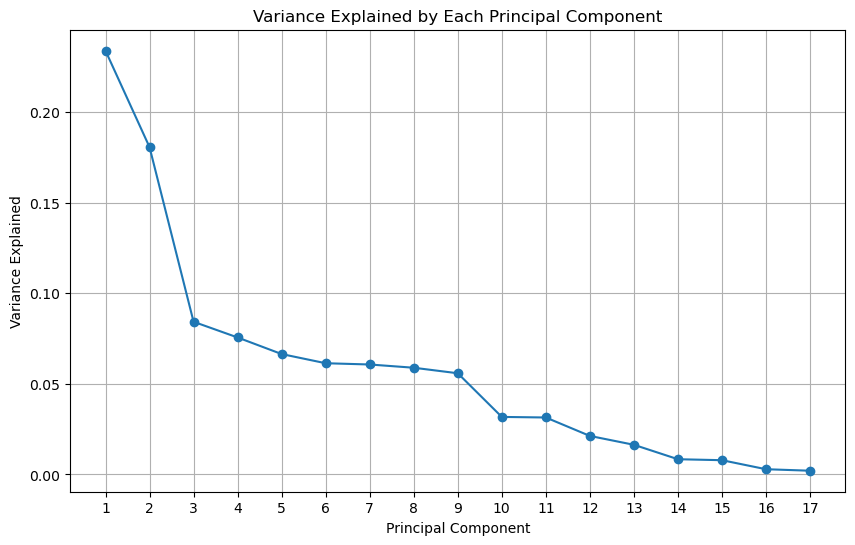

In [28]:
# import PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=X_cleaned.shape[1])
pca.fit(X_cleaned)

# plot variance explained by each component
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, marker='o')
plt.title('Variance Explained by Each Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.grid()
plt.show()